# Classical Model Performance And Stock-Level Examples

This notebook visualizes the classical logistic-regression models trained on deployable features only. The evaluated variants are:

- `price_only`: engineered price features.
- `text_only`: TF-IDF over post text.
- `text_price`: TF-IDF plus engineered price features.

`senti_label` and `emo_label` are not used as model inputs.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/marketmood-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.dates as mdates
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
PREDICTIONS_DIR = PROJECT_ROOT / "outputs" / "predictions"
PRICE_DIR = PROJECT_ROOT / "data" / "prices"

SELECTED_MODEL = "price_only"
SELECTED_TICKER = "TSLA"
CHART_START = "2020-01-01"
CHART_END = "2020-04-30"
LABEL_ORDER = ["negative", "neutral", "positive"]
CLASS_COLORS = {"negative": "#D55E00", "neutral": "#777777", "positive": "#0072B2"}
MODEL_LABELS = {
    "price_only": "Classical price-only",
    "text_only": "Classical text-only",
    "text_price": "Classical text + price",
}

## Load Metrics And Predictions

In [2]:
experiment_summary = pd.read_csv(METRICS_DIR / "experiment_summary.csv")
with (METRICS_DIR / "classical_metrics.json").open("r", encoding="utf-8") as file:
    classical_metrics = json.load(file)
with (METRICS_DIR / "classical_validation_metrics.json").open("r", encoding="utf-8") as file:
    validation_metrics = json.load(file)

prediction_frames = {
    variant: pd.read_csv(
        PREDICTIONS_DIR / f"classical_{variant}_test_predictions.csv",
        parse_dates=["post_date", "event_date"],
    )
    for variant in ["price_only", "text_only", "text_price"]
}

best_validation_model = validation_metrics["best_model"]
selected_predictions = prediction_frames[SELECTED_MODEL]

best_validation_model, selected_predictions.shape

('price_only', (994, 11))

## Model Comparison

In [3]:
comparison = experiment_summary.copy()
comparison["display_name"] = comparison["model"].replace(
    {
        "technical_analysis_baseline": "TA baseline",
        "classical_price_only": "Classical price-only",
        "classical_text_only": "Classical text-only",
        "classical_text_price": "Classical text + price",
    }
)
comparison[["display_name", "accuracy", "macro_f1", "weighted_f1", "n_rows"]].round(3)

,display_name,accuracy,macro_f1,weighted_f1,n_rows
0,Classical price-only,0.497,0.464,0.511,994
1,Classical text + price,0.504,0.457,0.512,994
2,TA baseline,0.476,0.412,0.475,994
3,Classical text-only,0.416,0.365,0.424,994


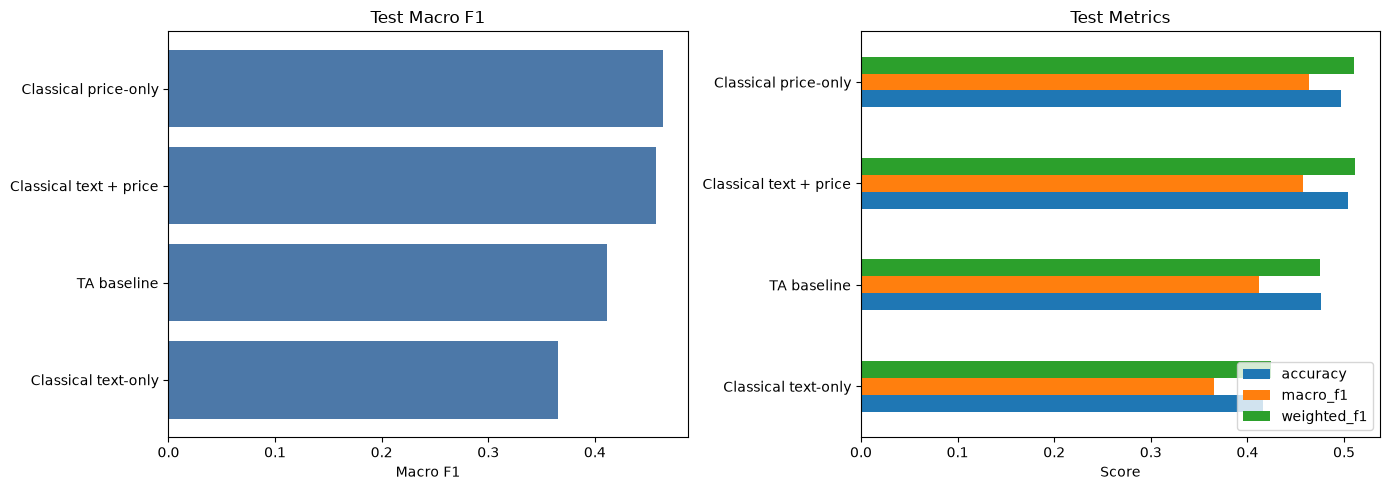

In [4]:
plot_frame = comparison.sort_values("macro_f1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_frame["display_name"], plot_frame["macro_f1"], color="#4C78A8")
axes[0].set_title("Test Macro F1")
axes[0].set_xlabel("Macro F1")

metric_plot = comparison.set_index("display_name")[["accuracy", "macro_f1", "weighted_f1"]]
metric_plot.loc[plot_frame["display_name"]].plot(kind="barh", ax=axes[1])
axes[1].set_title("Test Metrics")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("")
axes[1].legend(loc="lower right")

plt.tight_layout()

## Classical Model Confusion Matrices

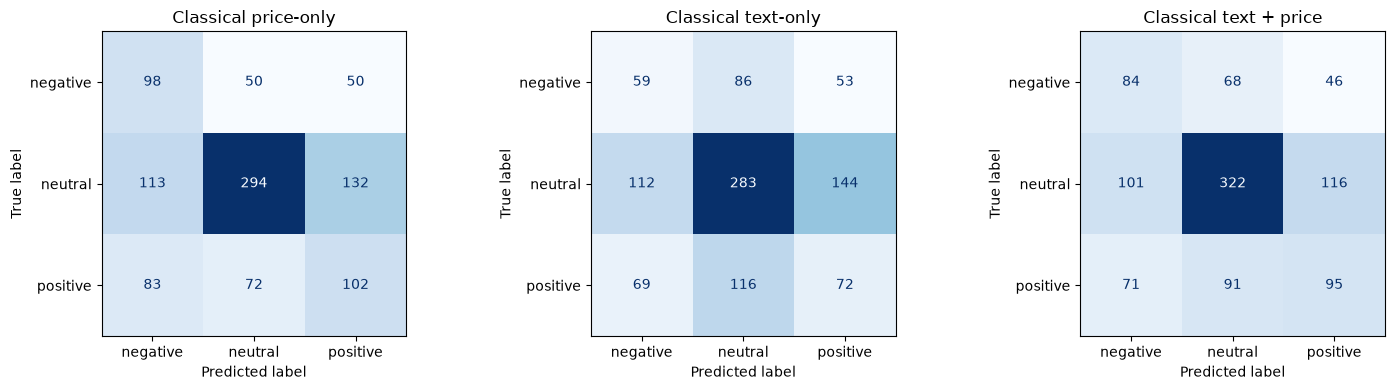

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, variant in zip(axes, ["price_only", "text_only", "text_price"], strict=True):
    frame = prediction_frames[variant]
    matrix = confusion_matrix(frame["true_label"], frame["predicted_label"], labels=LABEL_ORDER)
    ConfusionMatrixDisplay(matrix, display_labels=LABEL_ORDER).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set_title(MODEL_LABELS[variant])

plt.tight_layout()

## Prediction Mix By Variant

predicted_label,negative,neutral,positive
Classical price-only,0.296,0.419,0.286
Classical text-only,0.241,0.488,0.271
Classical text + price,0.258,0.484,0.259


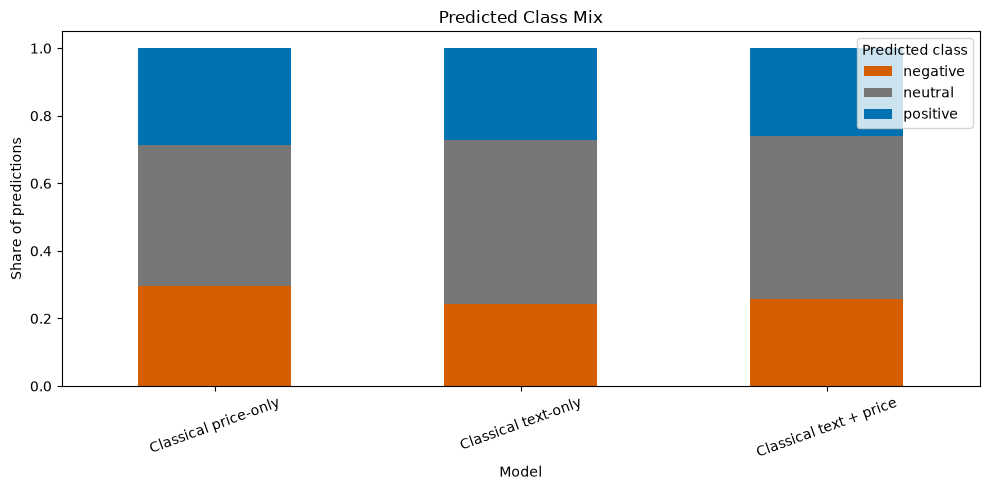

In [6]:
prediction_mix = pd.DataFrame(
    {
        MODEL_LABELS[variant]: frame["predicted_label"].value_counts(normalize=True).reindex(LABEL_ORDER)
        for variant, frame in prediction_frames.items()
    }
).T

display(prediction_mix.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
prediction_mix.plot(kind="bar", stacked=True, ax=ax, color=[CLASS_COLORS[label] for label in LABEL_ORDER])
ax.set_title("Predicted Class Mix")
ax.set_xlabel("Model")
ax.set_ylabel("Share of predictions")
ax.legend(title="Predicted class", loc="upper right")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

## Per-Ticker Performance

In [7]:
def macro_f1(group: pd.DataFrame) -> float:
    return f1_score(group["true_label"], group["predicted_label"], labels=LABEL_ORDER, average="macro", zero_division=0)


ticker_summary = (
    selected_predictions.groupby("ticker")
    .apply(
        lambda group: pd.Series(
            {
                "rows": len(group),
                "accuracy": (group["true_label"] == group["predicted_label"]).mean(),
                "macro_f1": macro_f1(group),
                "predicted_positive_rate": (group["predicted_label"] == "positive").mean(),
                "predicted_negative_rate": (group["predicted_label"] == "negative").mean(),
            }
        ),
        include_groups=False,
    )
    .sort_values(["rows", "macro_f1"], ascending=[False, False])
)

ticker_summary.head(15).round(3)

,rows,accuracy,macro_f1,predicted_positive_rate,predicted_negative_rate
ticker,,,,,
TSLA,426.0,0.570,0.494,0.185,0.279
AAPL,167.0,0.443,0.444,0.473,0.275
BA,88.0,0.420,0.370,0.125,0.420
DIS,41.0,0.634,0.624,0.268,0.488
AMZN,39.0,0.179,0.188,0.333,0.436
MSFT,35.0,0.457,0.412,0.600,0.114
CCL,33.0,0.667,0.642,0.182,0.212
BABA,28.0,0.500,0.507,0.357,0.393
FB,22.0,0.455,0.463,0.318,0.455


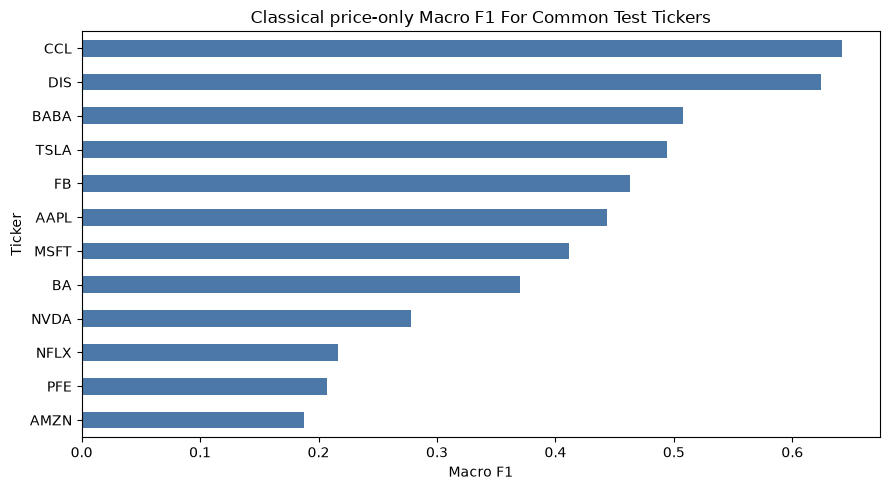

In [8]:
top_tickers = ticker_summary.head(12).sort_values("macro_f1")

fig, ax = plt.subplots(figsize=(9, 5))
top_tickers["macro_f1"].plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title(f"{MODEL_LABELS[SELECTED_MODEL]} Macro F1 For Common Test Tickers")
ax.set_xlabel("Macro F1")
ax.set_ylabel("Ticker")
plt.tight_layout()

## Selected Stock Example

Change `SELECTED_MODEL`, `SELECTED_TICKER`, `CHART_START`, and `CHART_END` in the setup cell to inspect a different stock or model variant.

In [9]:
ticker_predictions = selected_predictions.loc[selected_predictions["ticker"].eq(SELECTED_TICKER)].copy()
ticker_predictions = ticker_predictions.sort_values("event_date")

price_path = PRICE_DIR / f"{SELECTED_TICKER}.csv"
prices = pd.read_csv(price_path, parse_dates=["date"]).sort_values("date")
chart_prices = prices.loc[
    prices["date"].between(pd.Timestamp(CHART_START), pd.Timestamp(CHART_END))
].copy()
chart_predictions = ticker_predictions.loc[
    ticker_predictions["event_date"].between(pd.Timestamp(CHART_START), pd.Timestamp(CHART_END))
].copy()

ticker_rule_summary = pd.Series(
    {
        "model": MODEL_LABELS[SELECTED_MODEL],
        "ticker": SELECTED_TICKER,
        "test_rows": len(ticker_predictions),
        "chart_rows": len(chart_predictions),
        "ticker_accuracy": (ticker_predictions["true_label"] == ticker_predictions["predicted_label"]).mean(),
        "ticker_macro_f1": macro_f1(ticker_predictions),
    }
).to_frame("value")

ticker_rule_summary

,value
model,Classical price-only
ticker,TSLA
test_rows,426
chart_rows,143
ticker_accuracy,0.570423
ticker_macro_f1,0.494209


## Candlesticks With Classical Predictions

Markers show the selected classical model's predictions on event dates. Marker fill color is the predicted class; marker edge color is the true target class.

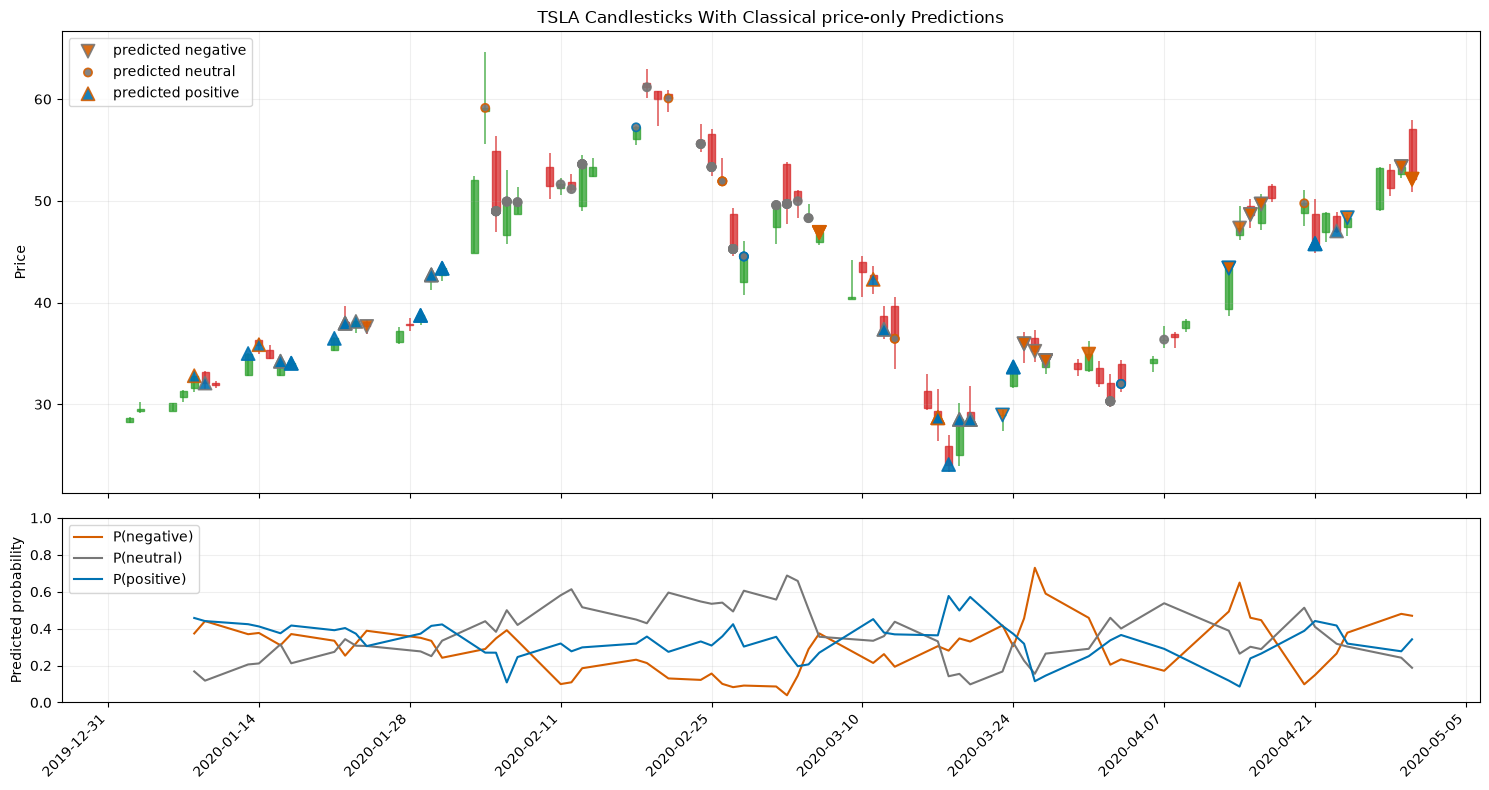

In [10]:
def plot_candlesticks(ax, price_frame: pd.DataFrame, width: float = 0.65) -> None:
    for row in price_frame.itertuples(index=False):
        date_num = mdates.date2num(row.date)
        open_price = row.open
        close_price = row.close
        high_price = row.high
        low_price = row.low
        color = "#2CA02C" if close_price >= open_price else "#D62728"
        lower = min(open_price, close_price)
        height = abs(close_price - open_price)
        ax.vlines(date_num, low_price, high_price, color=color, linewidth=1.1, alpha=0.8)
        ax.add_patch(
            patches.Rectangle(
                (date_num - width / 2, lower),
                width,
                max(height, 0.01),
                facecolor=color,
                edgecolor=color,
                alpha=0.75,
            )
        )


fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1.2]})

plot_candlesticks(axes[0], chart_prices)
axes[0].set_title(f"{SELECTED_TICKER} Candlesticks With {MODEL_LABELS[SELECTED_MODEL]} Predictions")
axes[0].set_ylabel("Price")

marker_map = {"positive": "^", "neutral": "o", "negative": "v"}
size_map = {"positive": 90, "neutral": 35, "negative": 90}
price_lookup = chart_prices.set_index("date")["close"]

for label in LABEL_ORDER:
    subset = chart_predictions.loc[chart_predictions["predicted_label"].eq(label)].copy()
    if subset.empty:
        continue
    subset["plot_price"] = subset["event_date"].map(price_lookup)
    subset = subset.dropna(subset=["plot_price"])
    axes[0].scatter(
        subset["event_date"],
        subset["plot_price"],
        marker=marker_map[label],
        s=size_map[label],
        color=CLASS_COLORS[label],
        edgecolor=subset["true_label"].map(CLASS_COLORS),
        linewidth=1.2,
        alpha=0.9,
        label=f"predicted {label}",
        zorder=5,
    )

axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.2)

axes[1].plot(chart_predictions["event_date"], chart_predictions["prob_negative"], color=CLASS_COLORS["negative"], label="P(negative)")
axes[1].plot(chart_predictions["event_date"], chart_predictions["prob_neutral"], color=CLASS_COLORS["neutral"], label="P(neutral)")
axes[1].plot(chart_predictions["event_date"], chart_predictions["prob_positive"], color=CLASS_COLORS["positive"], label="P(positive)")
axes[1].set_ylabel("Predicted probability")
axes[1].set_ylim(0, 1)
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.2)

axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Selected Ticker Examples

In [11]:
example_columns = [
    "event_date",
    "ticker",
    "true_label",
    "predicted_label",
    "prob_negative",
    "prob_neutral",
    "prob_positive",
    "original",
]

ticker_predictions.sort_values("event_date")[example_columns].head(20)

,event_date,ticker,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,original
5,2020-01-08,TSLA,negative,positive,0.373920,0.168308,0.457771,$TSLA I think we ready for that $510 ride Tesla. Yes we are ready. We got our seatbelts on 😂😂🔥🔥 🚀 🚀 🚀 🚀
7,2020-01-09,TSLA,neutral,positive,0.440790,0.118261,0.440948,$TSLA the market is giving away money rn and bears refuse it. They prefer the path of greatest resistance. 🤷🏽‍♂️
13,2020-01-13,TSLA,positive,positive,0.369915,0.206000,0.424085,$TSLA when do i buy?? Waaaaaa 😭😭
15,2020-01-14,TSLA,negative,positive,0.376635,0.211431,0.411934,$TSLA Realistically I think ER COULD go either way.. I’m thinking of a straddle mostly bearish though because revenue could be abit low.. however straddles ...
20,2020-01-16,TSLA,neutral,positive,0.310131,0.314892,0.374977,$TSLA you may have a gambling problem if you’re buying here. 🤷‍♂️ do as you wish
21,2020-01-16,TSLA,neutral,positive,0.310131,0.314892,0.374977,"$TSLA who called the top here ? When everybody thought was crazy. Me moFos, me ! 🧙‍♂️"
23,2020-01-17,TSLA,positive,positive,0.370687,0.212378,0.416935,$TSLA anyone believes it’ll hit 496$ today ??🤚🏼
24,2020-01-17,TSLA,positive,positive,0.370687,0.212378,0.416935,$TSLA get ready to make an appointment to get in line for your appointment to fix issues Tesla owners 😳
25,2020-01-21,TSLA,positive,positive,0.334411,0.274039,0.391550,$TSLA down 6$ afterhours right now 🤔
29,2020-01-22,TSLA,neutral,positive,0.253771,0.343026,0.403203,$TSLA tweet from Ross Gerber. Cool 😎 one🍷🍀🚀🤗


## Misclassification Examples And Likely Root Causes

In [12]:
def classify_classical_error(row: pd.Series) -> str:
    if row["true_label"] == row["predicted_label"]:
        return "correct"
    if row["predicted_label"] == "neutral":
        return "missed_directional_move"
    if row["true_label"] == "neutral":
        return "false_directional_prediction"
    return "opposite_direction"


def classical_root_cause(row: pd.Series) -> str:
    if row["error_type"] == "missed_directional_move":
        return "Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff."
    if row["error_type"] == "false_directional_prediction":
        return "Features resembled directional cases, but the realized next-day return stayed inside the neutral threshold; likely noisy language or a failed setup."
    if SELECTED_MODEL == "text_only":
        return "Text tone or topic pointed the wrong way for realized return; likely hype, sarcasm, ambiguity, or a market reversal after the post."
    if SELECTED_MODEL == "price_only":
        return "Price setup pointed one way, but the next-day move reversed; price-only context cannot observe post-specific catalysts."
    return "Combined text and price signal conflicted with the realized move; likely ambiguous text, external news, or noisy short-horizon price action."


classical_errors = selected_predictions.loc[
    selected_predictions["true_label"].ne(selected_predictions["predicted_label"])
].copy()
probability_columns = ["prob_negative", "prob_neutral", "prob_positive"]
classical_errors["confidence"] = classical_errors[probability_columns].max(axis=1)
classical_errors["error_type"] = classical_errors.apply(classify_classical_error, axis=1)
classical_errors["likely_root_cause"] = classical_errors.apply(classical_root_cause, axis=1)

classical_error_summary = pd.crosstab(
    classical_errors["true_label"], classical_errors["predicted_label"], margins=True
)
display(classical_error_summary)
display(classical_errors["error_type"].value_counts().to_frame("rows"))

predicted_label,negative,neutral,positive,All
true_label,,,,
negative,0,50,50,100
neutral,113,0,132,245
positive,83,72,0,155
All,196,122,182,500


,rows
error_type,
false_directional_prediction,245
opposite_direction,133
missed_directional_move,122


In [13]:
classical_error_columns = [
    "ticker",
    "event_date",
    "true_label",
    "predicted_label",
    "error_type",
    "prob_negative",
    "prob_neutral",
    "prob_positive",
    "confidence",
    "likely_root_cause",
    "original",
]

representative_classical_errors = (
    classical_errors.sort_values("confidence", ascending=False)
    .groupby("error_type", group_keys=False)
    .head(3)[classical_error_columns]
    .reset_index(drop=True)
)
representative_classical_errors

,ticker,event_date,true_label,predicted_label,error_type,prob_negative,prob_neutral,prob_positive,confidence,likely_root_cause,original
0,CCL,2020-11-11,negative,neutral,missed_directional_move,0.160267,0.813552,0.026181,0.813552,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,$CCL The Pfizer Scam was a great way of luring retail money back into the market. Well done 👏
1,CCL,2020-05-27,negative,neutral,missed_directional_move,0.058609,0.776934,0.164457,0.776934,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,$CCL oh yea! Let's get another 10% day tomorrow 🤑
2,TSLA,2020-09-14,positive,neutral,missed_directional_move,0.070199,0.751939,0.177861,0.751939,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,$TSLA today was a decent day. Need $500 tomorrow to make it even against the 🐻.
3,BA,2020-03-16,neutral,positive,false_directional_prediction,0.150145,0.100734,0.749121,0.749121,"Features resembled directional cases, but the realized next-day return stayed inside the neutral threshold; likely noisy language or a failed setup.",$BA Huge Downgrades!!! Future contracts Cancelled! Going Down Big!👇👇👇
4,TSLA,2020-03-26,neutral,negative,false_directional_prediction,0.729649,0.155236,0.115115,0.729649,"Features resembled directional cases, but the realized next-day return stayed inside the neutral threshold; likely noisy language or a failed setup.",$TSLA let the Cubs buy those puts 😉 big bear has exit strategy set at a moment's notice news in wings eagles
5,BA,2020-03-27,neutral,negative,false_directional_prediction,0.705628,0.153246,0.141126,0.705628,"Features resembled directional cases, but the realized next-day return stayed inside the neutral threshold; likely noisy language or a failed setup.",$BA $241 to $155 in 1 week now five me $155 to $241 in 1 week 🏄🏻‍♂️🏄🏻‍♂️😊
6,BA,2020-01-22,positive,negative,opposite_direction,0.678355,0.062538,0.259107,0.678355,"Price setup pointed one way, but the next-day move reversed; price-only context cannot observe post-specific catalysts.",$BA can someone tell me why they haven’t downgraded this garbage 🗑 yet $265
7,TSLA,2020-05-01,positive,negative,opposite_direction,0.535153,0.132493,0.332354,0.535153,"Price setup pointed one way, but the next-day move reversed; price-only context cannot observe post-specific catalysts.",$TSLA all you new Tesla bulls realize why veterans are short this stock \nThanks for 28k two day paycheck Elon 😘
8,TSLA,2020-05-01,positive,negative,opposite_direction,0.535153,0.132493,0.332354,0.535153,"Price setup pointed one way, but the next-day move reversed; price-only context cannot observe post-specific catalysts.",$TSLA HAHAHAHAHAHAAHAHA DO YOU BULLS STILL NOT BELIEVE THIS STOCK IS A COMPLETE FRAUD?!!🤡🤡🤡🤦‍♂️🤦‍♂️


In [14]:
selected_ticker_errors = classical_errors.loc[classical_errors["ticker"].eq(SELECTED_TICKER)]
selected_ticker_errors.sort_values("confidence", ascending=False)[classical_error_columns].head(10)

,ticker,event_date,true_label,predicted_label,error_type,prob_negative,prob_neutral,prob_positive,confidence,likely_root_cause,original
708,TSLA,2020-09-14,positive,neutral,missed_directional_move,0.070199,0.751939,0.177861,0.751939,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,$TSLA today was a decent day. Need $500 tomorrow to make it even against the 🐻.
707,TSLA,2020-09-14,positive,neutral,missed_directional_move,0.070199,0.751939,0.177861,0.751939,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,$TSLA in my opinion tesla should continue to run the rest of this week due to the battery day catalyst 🤷‍♂️
251,TSLA,2020-03-26,neutral,negative,false_directional_prediction,0.729649,0.155236,0.115115,0.729649,"Features resembled directional cases, but the realized next-day return stayed inside the neutral threshold; likely noisy language or a failed setup.",$TSLA let the Cubs buy those puts 😉 big bear has exit strategy set at a moment's notice news in wings eagles
298,TSLA,2020-04-14,neutral,negative,false_directional_prediction,0.649617,0.264302,0.086082,0.649617,"Features resembled directional cases, but the realized next-day return stayed inside the neutral threshold; likely noisy language or a failed setup.",$TSLA Jim Chanos scratching his right now🤣
703,TSLA,2020-09-11,positive,neutral,missed_directional_move,0.110512,0.609005,0.280482,0.609005,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,"$TSLA come to think about it, I’m glad this company was not included in the s&p 500 index. Have you seen the performance of those stocks included? Abysmal s..."
704,TSLA,2020-09-11,positive,neutral,missed_directional_move,0.110512,0.609005,0.280482,0.609005,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,$TSLA ok you bears can go back to your graves now 😂
702,TSLA,2020-09-11,positive,neutral,missed_directional_move,0.110512,0.609005,0.280482,0.609005,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,$TSLA I see a lot of 420 should I light a blunt before market opens 😂🚀💪
705,TSLA,2020-09-11,positive,neutral,missed_directional_move,0.110512,0.609005,0.280482,0.609005,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,$TSLA Another split after battery day!!!💰💰💰💰💰💰💰💰😁😁😁🥂
144,TSLA,2020-02-28,positive,neutral,missed_directional_move,0.091595,0.605482,0.302923,0.605482,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,"$TSLA Fridayy EOM: bull run on open ➡️ trades closing for the month! Puts ready on highs, calls ready down below"
145,TSLA,2020-02-28,positive,neutral,missed_directional_move,0.091595,0.605482,0.302923,0.605482,Model assigned neutral despite an abnormal move; text and price context likely did not separate the event from routine chatter before the feature cutoff.,$TSLA shorts profit taking on Friday before next leg down and see how all bull roaches came out to celebrate $1000 run again 😂😂😂


## Prediction Agreement Across Classical Variants

In [15]:
agreement = selected_predictions[["id", "ticker", "event_date", "true_label", "original"]].copy()
for variant, frame in prediction_frames.items():
    agreement = agreement.merge(
        frame[["id", "predicted_label"]].rename(columns={"predicted_label": f"pred_{variant}"}),
        on="id",
        how="left",
    )

agreement["all_classical_agree"] = agreement[["pred_price_only", "pred_text_only", "pred_text_price"]].nunique(axis=1).eq(1)

display(agreement["all_classical_agree"].value_counts(normalize=True).rename("share").to_frame().round(3))
agreement.loc[agreement["ticker"].eq(SELECTED_TICKER)].head(20)

,share
all_classical_agree,
False,0.657
True,0.343


,id,ticker,event_date,true_label,original,pred_price_only,pred_text_only,pred_text_price,all_classical_agree
5,109004,TSLA,2020-01-08,negative,$TSLA I think we ready for that $510 ride Tesla. Yes we are ready. We got our seatbelts on 😂😂🔥🔥 🚀 🚀 🚀 🚀,positive,neutral,positive,False
7,109006,TSLA,2020-01-09,neutral,$TSLA the market is giving away money rn and bears refuse it. They prefer the path of greatest resistance. 🤷🏽‍♂️,positive,neutral,positive,False
13,109012,TSLA,2020-01-13,positive,$TSLA when do i buy?? Waaaaaa 😭😭,positive,neutral,positive,False
15,109013,TSLA,2020-01-14,negative,$TSLA Realistically I think ER COULD go either way.. I’m thinking of a straddle mostly bearish though because revenue could be abit low.. however straddles ...,positive,negative,negative,False
20,109018,TSLA,2020-01-16,neutral,$TSLA you may have a gambling problem if you’re buying here. 🤷‍♂️ do as you wish,positive,neutral,positive,False
21,109019,TSLA,2020-01-16,neutral,"$TSLA who called the top here ? When everybody thought was crazy. Me moFos, me ! 🧙‍♂️",positive,negative,negative,False
23,109020,TSLA,2020-01-17,positive,$TSLA anyone believes it’ll hit 496$ today ??🤚🏼,positive,positive,positive,True
24,109021,TSLA,2020-01-17,positive,$TSLA get ready to make an appointment to get in line for your appointment to fix issues Tesla owners 😳,positive,negative,negative,False
25,100234,TSLA,2020-01-21,positive,$TSLA down 6$ afterhours right now 🤔,positive,neutral,positive,False
29,109023,TSLA,2020-01-22,neutral,$TSLA tweet from Ross Gerber. Cool 😎 one🍷🍀🚀🤗,positive,neutral,positive,False
